# AI-Based Sentiment Analysis System using Machine Learning and NLP

### CodeAlpha Artificial Intelligence Internship

---

## Project Objective

The objective of this project is to build an Artificial Intelligence system capable of automatically classifying the sentiment of Twitter posts into **Positive**, **Negative**, and **Neutral** categories using Natural Language Processing (NLP) and Machine Learning techniques.

The project follows an end-to-end machine learning workflow, including:

- Data Collection
- Exploratory Data Analysis
- Data Cleaning
- Text Preprocessing
- Feature Engineering using TF-IDF
- Model Training
- Model Validation
- Performance Evaluation
- Model Deployment Preparation

---

### Dataset

- **Training Dataset:** `twitter_training.csv`
- **Validation Dataset:** `twitter_validation.csv`

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- Scikit-learn
- TF-IDF Vectorizer
- Logistic Regression
- Streamlit

---

### Author

**Panuganti Varshini**

CodeAlpha Artificial Intelligence Internship

**Install** **Required** **Libraries**

In [1]:
# ==========================================
# Install Required Libraries
# ==========================================

!pip install nltk
!pip install wordcloud
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.4 MB/s eta 0:00:00


**IMPORT REQUIRED LIBRARIES**

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import re
import string
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All required libraries imported successfully.")

All required libraries imported successfully.


**Upload Datasets**

In [3]:
# ==========================================
# Upload Training and Validation Datasets
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving twitter_training.csv to twitter_training.csv


**Load the Training Dataset**

In [4]:
# ============================================================
# Section 5: Load Training Dataset
# ============================================================

columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

train_df = pd.read_csv(
    "twitter_training.csv",
    names=columns
)

print("="*60)
print("Training Dataset Loaded Successfully")
print("="*60)

print(f"Dataset Shape : {train_df.shape}")

train_df.head()

Training Dataset Loaded Successfully
Dataset Shape : (74682, 4)


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


**Exploratory Data Analysis**

In [5]:
# ============================================================
# Dataset Information
# ============================================================

print("="*60)
print("Dataset Information")
print("="*60)

train_df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
# ============================================================
# Missing Values
# ============================================================

print("="*60)
print("Missing Values")
print("="*60)

train_df.isnull().sum()

Missing Values


,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [7]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = train_df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 2700


In [8]:
# ============================================================
# Sentiment Distribution
# ============================================================

train_df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


**Data Cleaning**

In [9]:
# ============================================================
# Remove Missing Values
# ============================================================

print("Before Cleaning :", train_df.shape)

train_df = train_df.dropna(subset=["Tweet"])

print("After Removing Missing Values :", train_df.shape)

Before Cleaning : (74682, 4)
After Removing Missing Values : (73996, 4)


In [10]:
# ============================================================
# Remove Duplicate Records
# ============================================================

train_df = train_df.drop_duplicates()

print("After Removing Duplicates :", train_df.shape)

After Removing Duplicates : (71656, 4)


In [11]:
# ============================================================
# Remove 'Irrelevant' Class
# ============================================================

"""
The 'Irrelevant' category does not represent
positive, negative or neutral sentiment.

It is removed to build a focused
three-class sentiment classifier.
"""

train_df = train_df[
    train_df["Sentiment"] != "Irrelevant"
]

train_df.reset_index(drop=True, inplace=True)

print(train_df["Sentiment"].value_counts())

Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64


Text Preprocessing

**Import NLP Libraries**

In [12]:
# ============================================================
# Import NLP Libraries
# ============================================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [13]:
# ============================================================
# Initialize NLP Objects
# ============================================================

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [14]:
# ============================================================
# Text Preprocessing Function
# ============================================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags (# but keep the word)
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords and lemmatize
    words = []

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)

In [15]:
# ============================================================
# Apply Text Preprocessing
# ============================================================

train_df["Clean_Tweet"] = train_df["Tweet"].apply(clean_text)

print("="*60)
print("Text Preprocessing Completed")
print("="*60)

train_df[["Tweet", "Clean_Tweet"]].head()

Text Preprocessing Completed


,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


In [16]:
# ============================================================
# Compare Original and Cleaned Text
# ============================================================

for i in range(5):

    print("="*80)

    print("Original Tweet:")
    print(train_df.loc[i, "Tweet"])

    print()

    print("Cleaned Tweet:")
    print(train_df.loc[i, "Clean_Tweet"])

    print()

Original Tweet:
im getting on borderlands and i will murder you all ,

Cleaned Tweet:
im getting borderland murder

Original Tweet:
I am coming to the borders and I will kill you all,

Cleaned Tweet:
coming border kill

Original Tweet:
im getting on borderlands and i will kill you all,

Cleaned Tweet:
im getting borderland kill

Original Tweet:
im coming on borderlands and i will murder you all,

Cleaned Tweet:
im coming borderland murder

Original Tweet:
im getting on borderlands 2 and i will murder you me all,

Cleaned Tweet:
im getting borderland murder



**Sentiment Distribution**

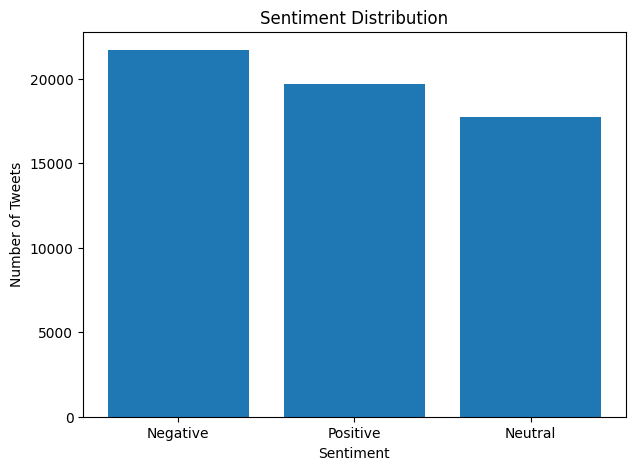

In [17]:
# ============================================================
# Sentiment Distribution
# ============================================================

import matplotlib.pyplot as plt

sentiment_counts = train_df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

**Pie Chart**

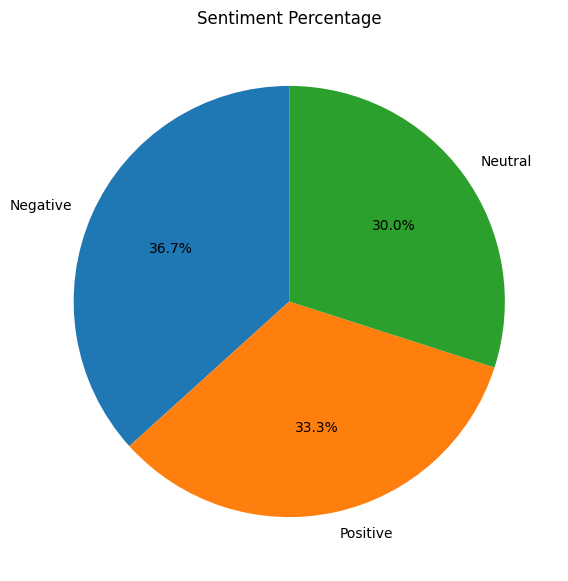

In [18]:
# ============================================================
# Sentiment Percentage
# ============================================================

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Percentage")

plt.show()

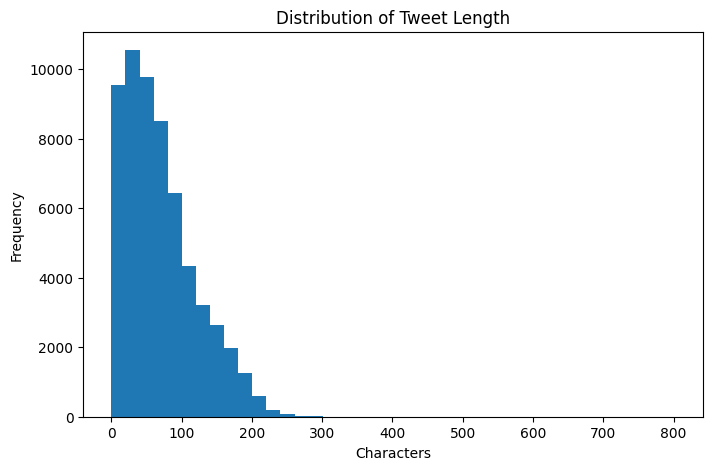

In [19]:
# ============================================================
# Tweet Length Distribution
# ============================================================

train_df["Tweet_Length"] = train_df["Clean_Tweet"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(
    train_df["Tweet_Length"],
    bins=40
)

plt.title("Distribution of Tweet Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [20]:
!pip install wordcloud

In [21]:
from wordcloud import WordCloud

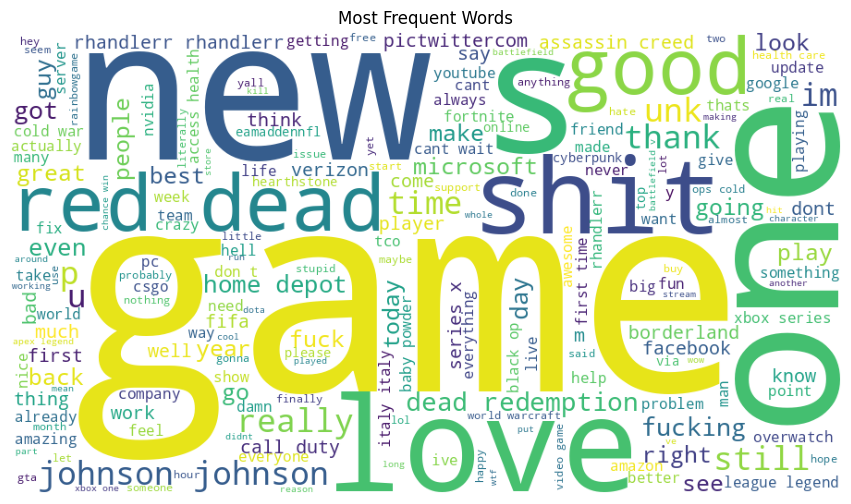

In [22]:
# ============================================================
# Word Cloud
# ============================================================

from wordcloud import WordCloud

text = " ".join(train_df["Clean_Tweet"])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words")

plt.show()

In [23]:
# ============================================================
# Import TF-IDF Vectorizer
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
# ============================================================
# Initialize TF-IDF Vectorizer
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

print("TF-IDF Vectorizer Created Successfully")

TF-IDF Vectorizer Created Successfully


In [25]:
# ============================================================
# Convert Tweets into TF-IDF Features
# ============================================================

X_train = tfidf_vectorizer.fit_transform(train_df["Clean_Tweet"])

print("="*60)
print("TF-IDF Matrix Created Successfully")
print("="*60)

print("Shape :", X_train.shape)

TF-IDF Matrix Created Successfully
Shape : (59119, 5000)


In [26]:
# ============================================================
# Vocabulary Size
# ============================================================

print("Total Vocabulary Size :")

print(len(tfidf_vectorizer.vocabulary_))

Total Vocabulary Size :
5000


In [27]:
# ============================================================
# Sample Vocabulary
# ============================================================

feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 30 Features")

print(feature_names[:30])

First 30 Features
['aaa' 'abandon' 'abandon sanction' 'ability' 'able' 'able play'
 'absolute' 'absolute best' 'absolutely' 'absolutely incredible'
 'absolutely love' 'absurd' 'abuse' 'abused' 'abusing' 'ac' 'ac game'
 'academy' 'acc' 'accept' 'acceptable' 'access' 'access health'
 'accessible' 'accident' 'accidentally' 'according' 'account'
 'account hacked' 'accurate']


In [28]:
# ============================================================
# Convert Cleaned Tweets into TF-IDF Features
# ============================================================

X_train = tfidf_vectorizer.fit_transform(train_df["Clean_Tweet"])

print("="*60)
print("TF-IDF Matrix Created Successfully")
print("="*60)

print("Shape:", X_train.shape)

TF-IDF Matrix Created Successfully
Shape: (59119, 5000)


In [29]:
from sklearn.preprocessing import LabelEncoder

In [30]:
# ============================================================
# Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["Sentiment"])

print("="*60)
print("Label Encoding Completed")
print("="*60)

print("Classes:")
print(label_encoder.classes_)

Label Encoding Completed
Classes:
['Negative' 'Neutral' 'Positive']


In [31]:
encoded_df = train_df[["Sentiment"]].copy()

encoded_df["Encoded"] = y_train

encoded_df.head(10)

,Sentiment,Encoded
0,Positive,2
1,Positive,2
2,Positive,2
3,Positive,2
4,Positive,2
5,Positive,2
6,Positive,2
7,Positive,2
8,Positive,2
9,Positive,2


In [32]:
# ============================================================
# Import Machine Learning Libraries
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [33]:
# ============================================================
# Train Logistic Regression Model
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("="*60)
print("Model Training Completed Successfully")
print("="*60)

Model Training Completed Successfully


In [34]:
# ============================================================
# Evaluate on Training Dataset
# ============================================================

train_predictions = model.predict(X_train)

training_accuracy = accuracy_score(
    y_train,
    train_predictions
)

print("="*60)
print("Training Accuracy")
print("="*60)

print(f"{training_accuracy*100:.2f}%")

Training Accuracy
79.32%


In [35]:
# ============================================================
# Training Classification Report
# ============================================================

print(classification_report(
    y_train,
    train_predictions,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.78      0.86      0.82     21698
     Neutral       0.80      0.71      0.75     17708
    Positive       0.80      0.79      0.80     19713

    accuracy                           0.79     59119
   macro avg       0.79      0.79      0.79     59119
weighted avg       0.79      0.79      0.79     59119



In [36]:
# ============================================================
# Training Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_train,
    train_predictions
)

print(cm)

[[18675  1501  1522]
 [ 2826 12627  2255]
 [ 2454  1668 15591]]


**Validation Dataset Evaluation**

In [37]:
# ============================================================
# Upload Validation Dataset
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving twitter_validation.csv to twitter_validation.csv


In [38]:
# ============================================================
# Load Validation Dataset
# ============================================================

validation_columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

validation_df = pd.read_csv(
    "twitter_validation.csv",
    header=None,
    names=validation_columns
)

print("="*60)
print("Validation Dataset Loaded Successfully")
print("="*60)

print(validation_df.shape)

validation_df.head()

Validation Dataset Loaded Successfully
(1000, 4)


,Tweet_ID,Entity,Sentiment,Tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [39]:
# ============================================================
# Remove Missing Values
# ============================================================

validation_df = validation_df.dropna(subset=["Tweet"])

# Remove Duplicate Tweets
validation_df = validation_df.drop_duplicates()

validation_df.reset_index(drop=True, inplace=True)

print(validation_df.shape)

(1000, 4)


In [40]:
# ============================================================
# Remove Irrelevant Class
# ============================================================

validation_df = validation_df[
    validation_df["Sentiment"] != "Irrelevant"
]

validation_df.reset_index(drop=True, inplace=True)

validation_df["Sentiment"].value_counts()

,count
Sentiment,
Neutral,285
Positive,277
Negative,266


In [41]:
validation_df["Clean_Tweet"] = validation_df["Tweet"].apply(clean_text)

validation_df.head()

,Tweet_ID,Entity,Sentiment,Tweet,Clean_Tweet
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon bos jeff bezos reject claim co...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...,pay word function poorly chromebook 🙄
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,...",csgo matchmaking full closet hacking truly awf...
3,4433,Google,Neutral,Now the President is slapping Americans in the...,president slapping american face really commit...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...,hi i’ve madeleine mccann cellar past year litt...


In [42]:
X_validation = tfidf_vectorizer.transform(
    validation_df["Clean_Tweet"]
)

print(X_validation.shape)

(828, 5000)


In [43]:
y_validation = label_encoder.transform(
    validation_df["Sentiment"]
)

In [44]:
validation_predictions = model.predict(
    X_validation
)

In [45]:
accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

print("="*60)
print("Validation Accuracy")
print("="*60)

print(f"{accuracy*100:.2f}%")

Validation Accuracy
83.82%


In [46]:
print(classification_report(
    y_validation,
    validation_predictions,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83       266
     Neutral       0.89      0.76      0.82       285
    Positive       0.85      0.87      0.86       277

    accuracy                           0.84       828
   macro avg       0.84      0.84      0.84       828
weighted avg       0.84      0.84      0.84       828



In [47]:
cm = confusion_matrix(
    y_validation,
    validation_predictions
)

print(cm)

[[234  15  17]
 [ 41 218  26]
 [ 23  12 242]]


In [48]:
# ============================================================
# Save Model Files
# ============================================================

import joblib

# Save trained model
joblib.dump(model, "sentiment_model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

# Save Label Encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("="*60)
print("All Model Files Saved Successfully")
print("="*60)

All Model Files Saved Successfully


In [49]:
import os

print("Generated Files:")
print("-"*40)

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Generated Files:
----------------------------------------
tfidf_vectorizer.pkl
label_encoder.pkl
sentiment_model.pkl


In [50]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
print(type(train_df))

<class 'pandas.core.frame.DataFrame'>


In [53]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [54]:
print(type(tfidf_vectorizer))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [55]:
print(type(label_encoder))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [56]:
print(accuracy)

0.8381642512077294


In [57]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


In [58]:
import os

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

tfidf_vectorizer.pkl
label_encoder.pkl
sentiment_model.pkl
